In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import math
from scipy.special import comb


# define the method for a rational b-spline
# a rational b-spline is required to make general conic sections

def plot_rational_bspline(control_points, weights, n_pts:int=30, plot_square:bool=True):
    N = control_points.shape[0] - 1

    u = np.linspace(0.0, 1.0, n_pts)
    x, y = np.zeros_like(u), np.zeros_like(u)
    denom = np.zeros_like(u)
    for i in range(N+1):
        nchoose_k = comb(N, i, exact=True)
        # nchoose_k = math.comb(N, i)
        bernstein_poly = nchoose_k * u**i * (1.0-u)**(N-i)
        point = control_points[i]
        x += bernstein_poly * point[0] * weights[i]
        y += bernstein_poly * point[1] * weights[i]
        denom += bernstein_poly * weights[i]
    x /= denom
    y /= denom

    plt.plot(x, y, 'o-')

    # draw also the control polygon
    for i in range(N):
        p1, p2 = control_points[i], control_points[i+1]
        x = p1[0] * (1-u) + p2[0] * u
        y = p1[1] * (1-u) + p2[1] * u
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'ko--')

    if plot_square:
        plt.axis('equal')

    plt.show()

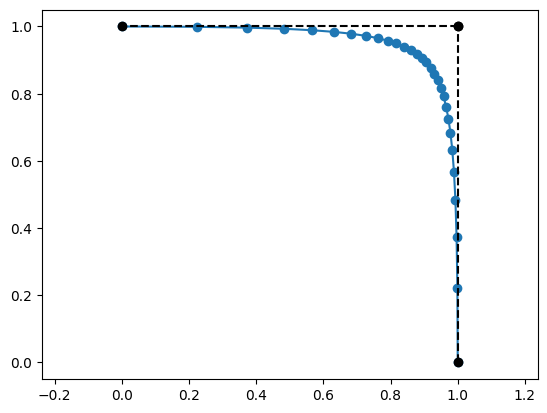

In [14]:
# plot a circular arc (with only three points on rational b-spline)

plot_rational_bspline(
    control_points=np.array([
        [1.0, 0.0],
        [1.0, 1.0],
        [0.0, 1.0]
    ]),
    weights=[1.0, 4.0, 1.0], # higher weights on 2nd one make super-ellipses lol
    n_pts=30
)

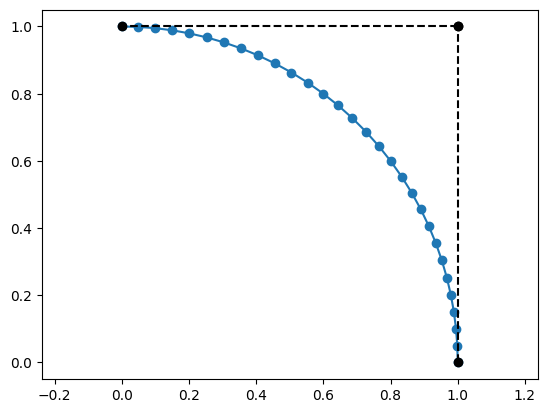

In [ ]:
# proper circular arc 90 degrees
plot_rational_bspline(
    control_points=np.array([
        [1.0, 0.0],
        [1.0, 1.0],
        [0.0, 1.0] 
    ]),
    weights=[1.0, 1.0/np.sqrt(2), 1.0],
    n_pts=30
)